# Exploratory Data Analysis для датасета матчей по CS2

Задача: бинарная классификация - предсказать, победит ли первая команда в матче (таргет - team1_win). Все необходимые функции написаны во внешних файлах. Посмотрим, что у нас в датасете:

In [1]:
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from src.preprocessing import load_raw, basic_clean, build_features

In [2]:
raw = load_raw()
print('raw shape:', raw.shape)
raw.head(3)

raw shape: (19031, 98)


,match_id,game_id,tournament,team1_id,team1,team2_id,team2,score1_match,score2_match,is_total,...,team2_player4_assists,team2_player4_adr,team2_player4_kast,team2_player4_kddiff,team2_player5_kills,team2_player5_deaths,team2_player5_assists,team2_player5_adr,team2_player5_kast,team2_player5_kddiff
0,7299109,153292.0,PGL Astana 2026. Closed European Qualifier,289672,magic,289673,K27,3.0,2.0,False,...,4.0,98.6,77.3,12.0,14.0,18.0,8.0,64.5,68.2,-4.0
1,7299109,153294.0,PGL Astana 2026. Closed European Qualifier,289672,magic,289673,K27,3.0,2.0,False,...,2.0,67.2,72.7,6.0,13.0,16.0,8.0,76.8,72.7,-3.0
2,7299109,-153292.0,PGL Astana 2026. Closed European Qualifier,289672,magic,289673,K27,3.0,2.0,True,...,6.0,82.9,75.0,18.0,27.0,34.0,16.0,70.7,70.5,-7.0


Поработаем с датасетом: избавимся от строк с isTotal = true (это агрегация по матчам без карт). Также проведём удаление строк с пропусками (map_name, bestOf, команды, время) и дубликаты по (match_id, game_id)

In [3]:
print('missing top10:')
print(raw.isna().sum().sort_values(ascending=False).head(10))
print('\nduplicates (match_id, game_id):', raw.duplicated(subset=['match_id','game_id']).sum())
print('is_total split:\n', raw['is_total'].value_counts())

missing top10:
map_id                   6710
map_name                 6710
score1_game              6663
score2_game              6663
team2_player5_kast       5508
team2_player5_kills      5508
team2_player5_adr        5508
team2_player5_assists    5508
team2_player5_deaths     5508
team2_player5            5508
dtype: int64

duplicates (match_id, game_id): 6
is_total split:
 is_total
False    9828
True     9203
Name: count, dtype: int64


In [4]:
df = basic_clean(raw)
print('cleaned shape:', df.shape)
print('date range:', df['datetime'].min(), '->', df['datetime'].max())
print('target balance:')
df['team1_win'].value_counts(normalize=True)

cleaned shape: (9731, 98)
date range: 2023-10-25 18:00:00 -> 2026-04-03 17:00:00
target balance:


team1_win
1    0.53756
0    0.46244
Name: proportion, dtype: float64

Проведём визуализации (распределение таргета, распределение матчей по картам, винрейт по картам и т.д.). Дополнительно всё экспортировано как картинки в /report/images

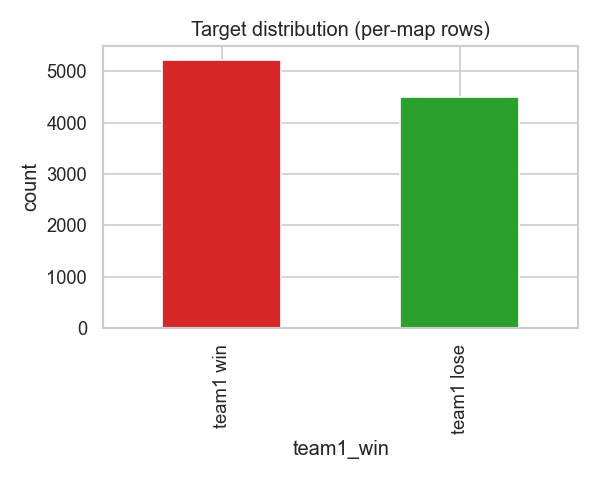

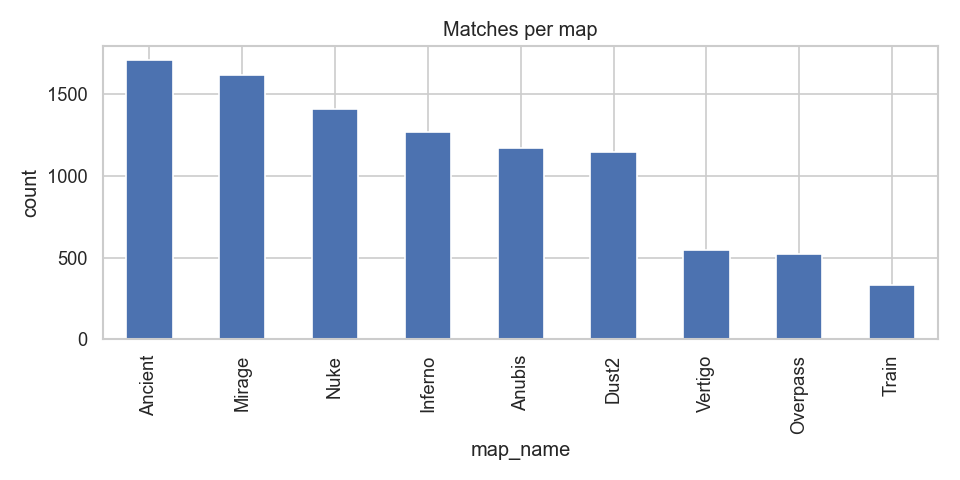

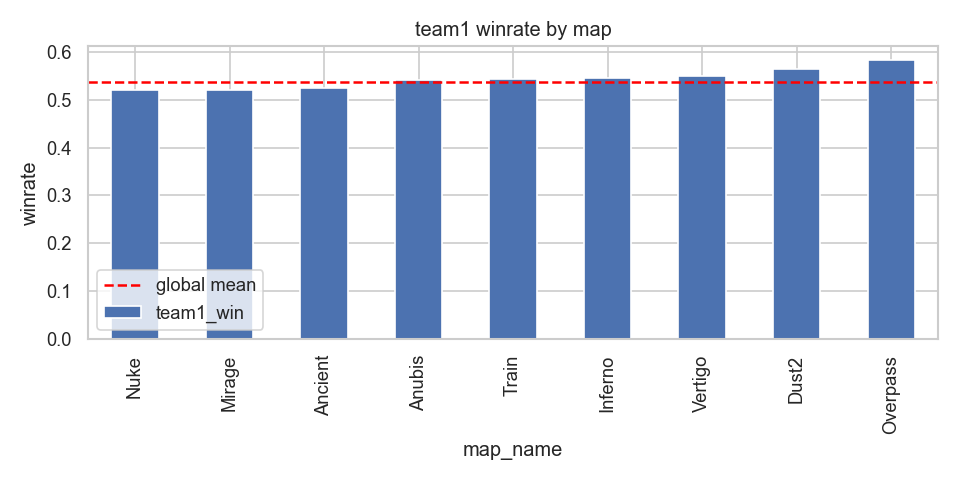

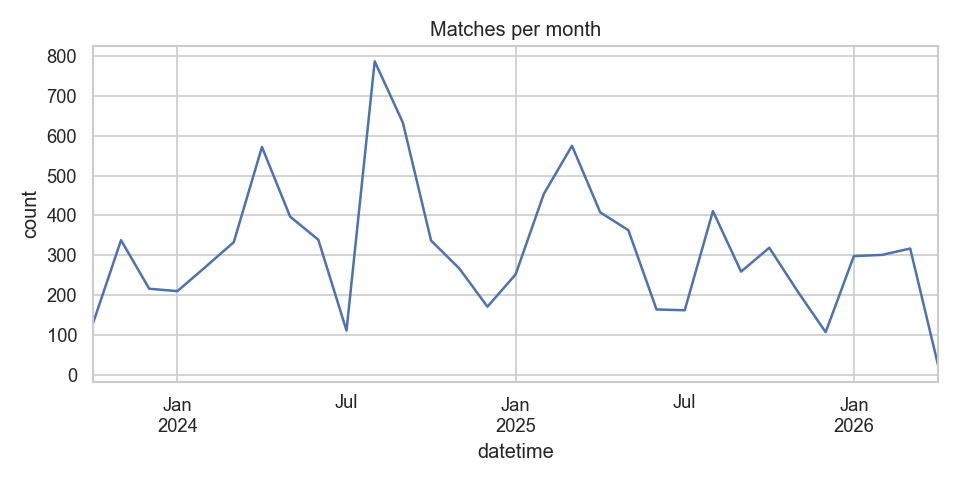

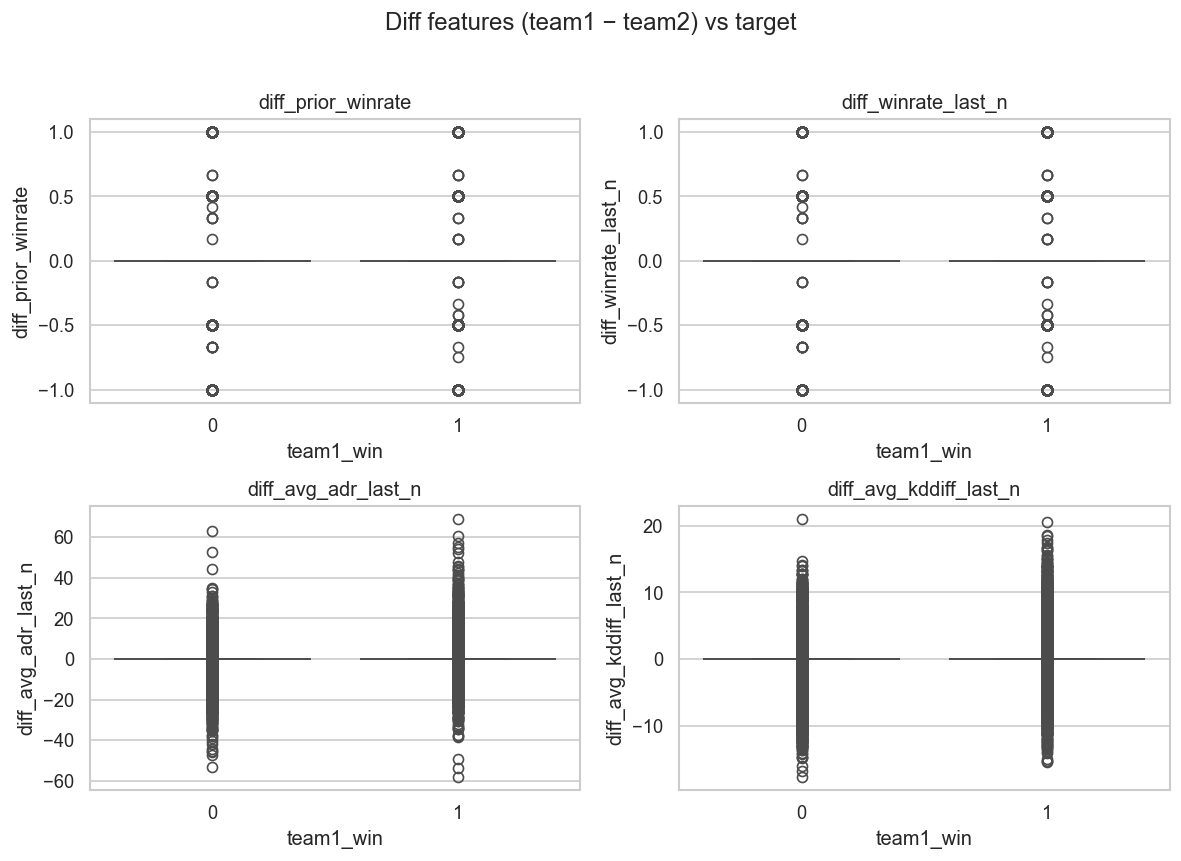

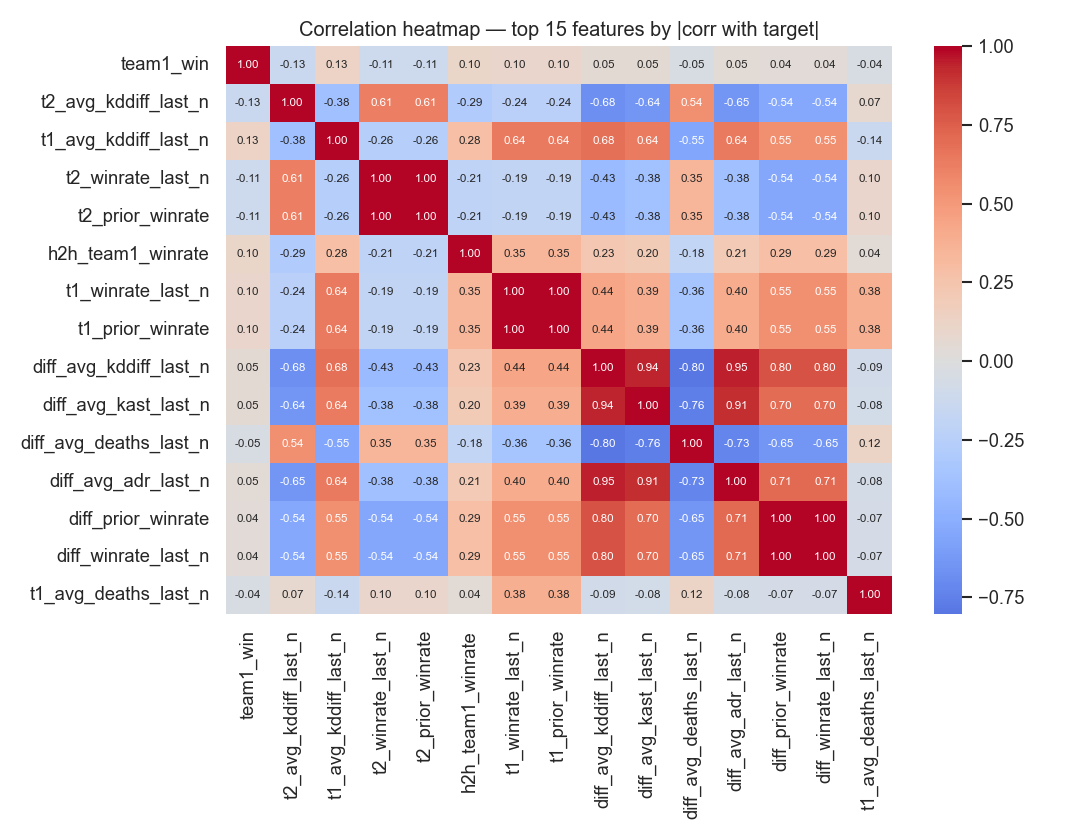

In [5]:
from IPython.display import Image, display
for img in ['01_target_balance.png','02_map_counts.png','03_winrate_by_map.png',
            '04_matches_over_time.png','05_diff_features_vs_target.png','06_corr_heatmap.png']:
    display(Image(f'report/images/{img}'))

## Про дополнительные фичи

Датасет состоит из статистики после матча (сколько за матч было K|D|A) - для модели это будет заглядыванием в будущее. Поэтому было принято решение строить скользящие исторические признаки: prior_winrate и winrate_last_n - общий и за последние N карт до текущего матча, по каждой команде (по умолчание N=10), map_prior_winrate - исторический винрейт команды на этой карте, avg_stat_last_n - средние статы команды за последние N карт. h2h_team1_winrate - исторический винрейт двух команд при встречах лицом к лицу. diff_* - разности по каждой из фич выше, и календарные (year, month, dayofweek, hour)

In [ ]:
feats = build_features(df)
print('features shape:', feats.shape)
print('columns:', list(feats.columns))

features shape: (9731, 49)
columns: ['game_id', 'match_id', 'datetime', 'tournament', 'map_name', 'bestOf', 'team1_id', 'team2_id', 'team1_win', 't1_team_id', 't1_games_played', 't1_prior_winrate', 't1_winrate_last_n', 't1_map_games_played', 't1_map_prior_winrate', 't1_avg_kills_last_n', 't1_avg_deaths_last_n', 't1_avg_assists_last_n', 't1_avg_adr_last_n', 't1_avg_kast_last_n', 't1_avg_kddiff_last_n', 't2_team_id', 't2_games_played', 't2_prior_winrate', 't2_winrate_last_n', 't2_map_games_played', 't2_map_prior_winrate', 't2_avg_kills_last_n', 't2_avg_deaths_last_n', 't2_avg_assists_last_n', 't2_avg_adr_last_n', 't2_avg_kast_last_n', 't2_avg_kddiff_last_n', 'diff_prior_winrate', 'diff_winrate_last_n', 'diff_map_prior_winrate', 'diff_games_played', 'diff_map_games_played', 'diff_avg_kills_last_n', 'diff_avg_deaths_last_n', 'diff_avg_assists_last_n', 'diff_avg_adr_last_n', 'diff_avg_kast_last_n', 'diff_avg_kddiff_last_n', 'h2h_team1_winrate', 'year', 'month', 'dayofweek', 'hour']


### Выводы по визуализациям (EDA):
1. **Баланс классов**: Таргет относительно сбалансирован (~53% побед team1). Легкий дисбаланс не требует сложных техник балансировки, но оправдывает выбор ROC-AUC как основной метрики.
2. **Популярность карт и винрейт**: Частоты выбора карт различаются (например, Mirage, Inferno наиболее популярны). Винрейт team1 также варьируется в зависимости от карты, что делает карту важным категориальным признаком.
3. **Распределение во времени**: Данные распределены по времени неравномерно. Это подтверждает необходимость использования `TimeSeriesSplit` при кросс-валидации.
4. **Корреляции (diff-признаки)**: Разницы в статистике команд (diff_score, diff_rating) имеют заметную корреляцию с таргетом, что подтверждает гипотезу об их высокой предсказательной силе.